In [2]:
import sys
sys.path.append("..")

In [3]:
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from pathlib import Path

from src.model import CardinalityEstimator
from src.dataset import GalacticBinariesDataset
from config import val_dataset_path, BATCH_SIZE, MAX_K

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

ckpt_path = Path("../runs/run_20260506_132421/checkpoints/best_checkpoint.pth")

model = CardinalityEstimator().to(device)
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

CardinalityEstimator(
  (conv_encoder): Sequential(
    (conv_1): Conv1d(4, 32, kernel_size=(8,), stride=(2,), padding=(3,))
    (gelu_1): GELU(approximate='none')
    (conv_2): Conv1d(32, 64, kernel_size=(8,), stride=(2,), padding=(3,))
    (gelu_2): GELU(approximate='none')
    (conv_3): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(3,))
  )
  (pos_encoder): PosEnc()
  (MHAttention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (pooling): PoolingConcat(
    (attn): Linear(in_features=128, out_features=128, bias=True)
    (context_vec): Linear(in_features=128, out_features=1, bias=False)
  )
  (classifier): Sequential(
    (fc_1): Linear(in_features=384, out_features=256, bias=True)
    (gelu_1): GELU(approximate='none')
    (fc_2): Linear(in_features=256, out_features=1, bias=True)
  )
)

In [5]:
val_ds = GalacticBinariesDataset(
    val_dataset_path,
    max_K=10,
    max_samples=10_000,
    noise=True,
    deterministic=True,
    seed=0,
)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

[05/06/26 15:59:37] INFO     Loading 10000 waveforms in memory...

[05/06/26 15:59:38] INFO     Loading parameters amp, beta, f0, fddot, fdot, iota, lam, phi0, psi, snr in memory...

In [6]:
rows = []

with torch.no_grad():
    offset = 0
    for summed_waveform, targets in val_loader:
        X = torch.as_tensor(summed_waveform, dtype=torch.float32, device=device)
        targets = torch.as_tensor(targets, dtype=torch.long, device=device)
        y = targets.float().unsqueeze(1) / MAX_K

        logit = model(X)
        out = torch.sigmoid(logit)

        pred = torch.round(out * MAX_K).long().squeeze(1)
        conf = torch.max(out, 1 - out).squeeze(1)
        margin = torch.abs(out - 0.5) * 2
        nll = F.binary_cross_entropy(out, y, reduction="none").squeeze(1)

        for i in range(len(y)):
            rows.append({
                "idx": offset + i,
                "true_class": y[i].item(),
                "pred_class": out[i].item(),
                "true_K": targets[i].item(),
                "pred_K": pred[i].item(),
                "correct": pred[i].item() == targets[i].item(),
                "error": out[i].item() - y[i].item(),
                "abs_error": abs(pred[i].item() - targets[i].item()),
                "confidence": conf[i].item(),
                "margin": margin[i].item(),
                "nll": nll[i].item(),
            })

        offset += len(y)

df = pd.DataFrame(rows)
df.head()

,idx,true_class,pred_class,true_K,pred_K,correct,error,abs_error,confidence,margin,nll
0,0,0.9,0.953472,9,10,False,0.053472,1,0.953472,0.906945,0.349651
1,1,0.6,0.629939,6,6,True,0.029939,0,0.629939,0.259878,0.674914
2,2,0.9,0.908575,9,9,True,0.008575,0,0.908575,0.817150,0.325514
3,3,0.3,0.284950,3,3,True,-0.015050,0,0.715050,0.430100,0.611414
4,4,0.9,0.916626,9,9,True,0.016626,0,0.916626,0.833253,0.326792


In [7]:
print(f"Overall accuracy: {df.correct.mean():.4f}")

Overall accuracy: 0.8885


In [8]:
summary_by_k = (
    df.groupby("true_K")
    .agg(
        n=("idx", "count"),
        accuracy=("correct", "mean"),
        mae=("abs_error", "mean"),
        error=("error", "mean"),
        avg_confidence=("confidence", "mean"),
        avg_nll=("nll", "mean"),
    )
)

summary_by_k

,n,accuracy,mae,error,avg_confidence,avg_nll
true_K,,,,,,
1,981,1.000000,0.000000,0.008222,0.891778,0.325524
2,984,0.996951,0.003049,0.010678,0.789322,0.501071
3,1016,0.996063,0.003937,0.010329,0.689671,0.611542
4,1034,0.984526,0.015474,0.009095,0.590905,0.673849
5,947,0.938754,0.061246,0.010462,0.521448,0.694624
6,1036,0.883205,0.116795,0.012713,0.612879,0.675396
7,985,0.779695,0.220305,0.018570,0.718570,0.615145
8,990,0.709091,0.290909,0.023240,0.823240,0.508372
9,1013,0.707799,0.293189,0.019638,0.919638,0.346389


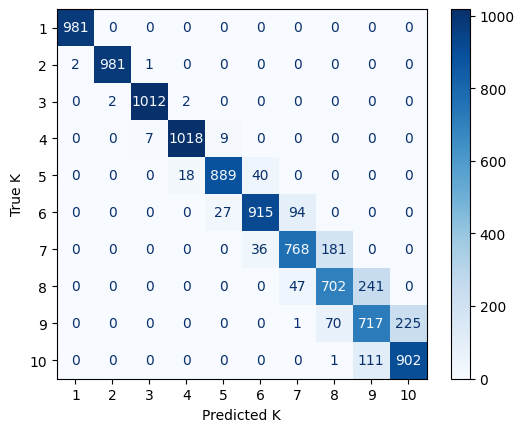

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(df.true_K, df.pred_K, labels=range(1, 11))
disp = ConfusionMatrixDisplay(cm, display_labels=range(1, 11))
disp.plot(cmap="Blues", values_format="d")
plt.xlabel("Predicted K")
plt.ylabel("True K")
plt.show()

abs_error
0    8885
1    1113
2       2
Name: count, dtype: int64


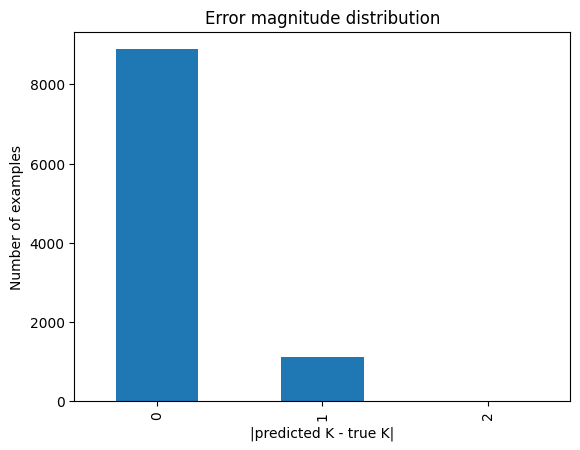

In [11]:
df["abs_error"].value_counts().sort_index().plot(kind="bar")
print(df["abs_error"].value_counts().sort_index())
plt.xlabel("|predicted K - true K|")
plt.ylabel("Number of examples")
plt.title("Error magnitude distribution")
plt.show()

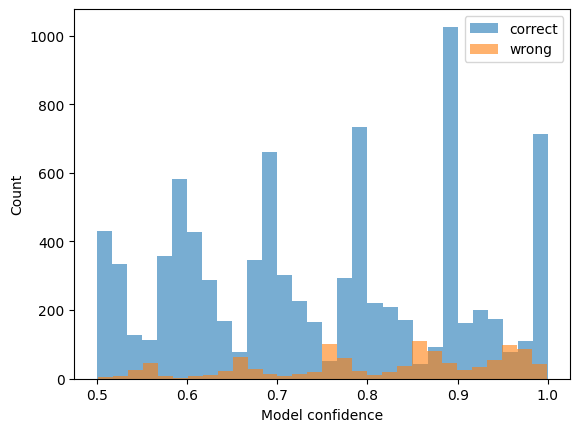

In [12]:
df.groupby("correct")[["confidence", "margin", "nll"]].describe()
plt.hist(df[df.correct].confidence, bins=30, alpha=0.6, label="correct")
plt.hist(df[~df.correct].confidence, bins=30, alpha=0.6, label="wrong")
plt.xlabel("Model confidence")
plt.ylabel("Count")
plt.legend()
plt.show()


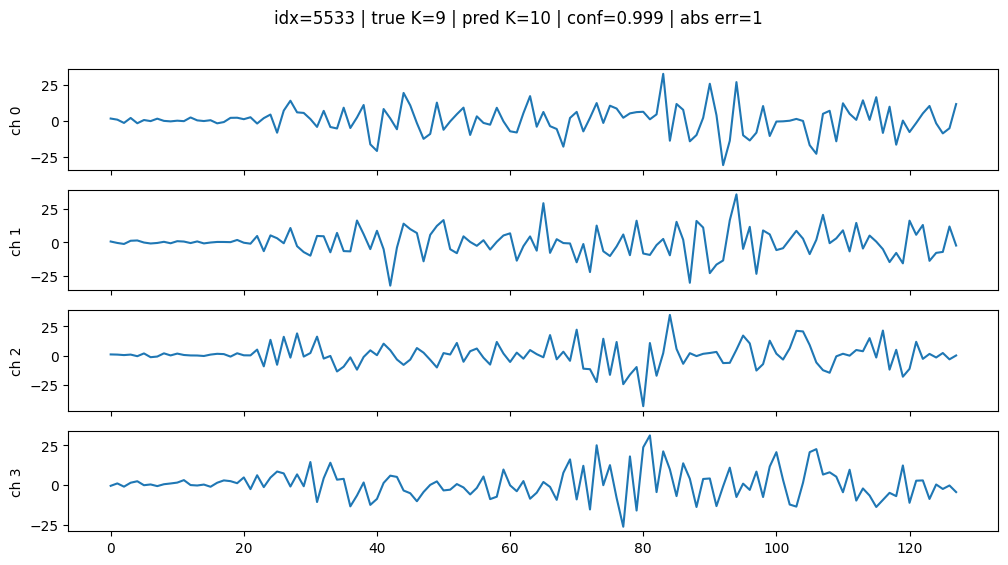

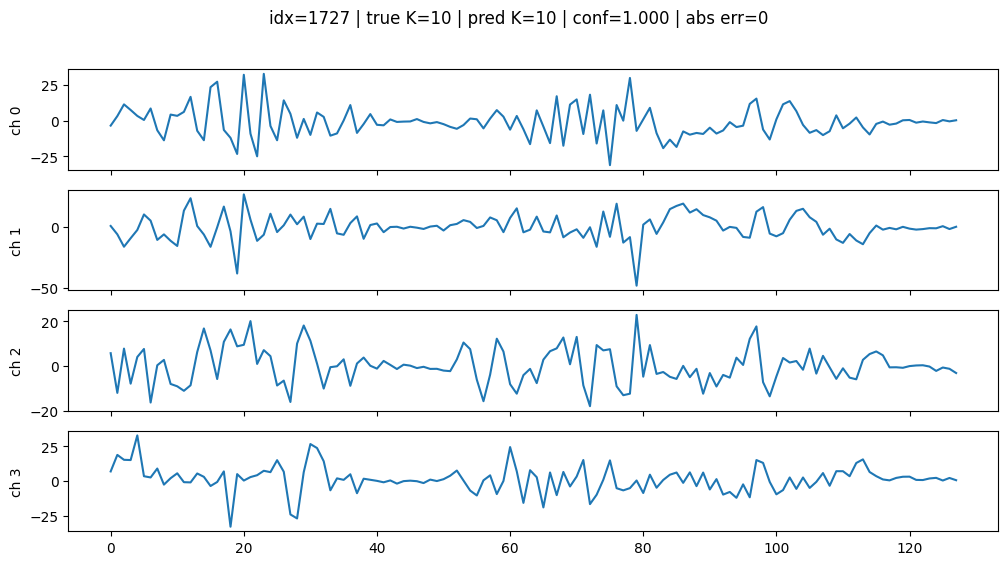

In [14]:
def plot_example(dataset, row):
    X, y = dataset[int(row.idx)]

    fig, axes = plt.subplots(X.shape[0], 1, figsize=(12, 6), sharex=True)
    for c, ax in enumerate(axes):
        ax.plot(X[c])
        ax.set_ylabel(f"ch {c}")

    fig.suptitle(
        f"idx={row.idx} | true K={row.true_K} | pred K={row.pred_K} | "
        f"conf={row.confidence:.3f} | abs err={row.abs_error}"
    )
    plt.show()

hard_wrong = df[~df.correct].sort_values("confidence", ascending=False).head(5)
easy_correct = df[df.correct].sort_values("confidence", ascending=False).head(5)

plot_example(val_ds, hard_wrong.iloc[0])
plot_example(val_ds, easy_correct.iloc[0])


In [15]:
def evaluate_with_noise_sigma(model, dataset, sigma):
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    rows = []

    with torch.no_grad():
        for X, y in loader:
            X = torch.as_tensor(X, dtype=torch.float32, device=device)
            y = torch.as_tensor(y, dtype=torch.long, device=device)

            if sigma > 0:
                X = X + sigma * torch.randn_like(X)

            pred = model(X).argmax(dim=1)
            abs_err = (pred - y).abs()

            rows.append(pd.DataFrame({
                "true_K": y.cpu().numpy() + 1,
                "pred_K": pred.cpu().numpy() + 1,
                "correct": (pred == y).cpu().numpy(),
                "abs_error": abs_err.cpu().numpy(),
                "sigma": sigma,
            }))

    return pd.concat(rows, ignore_index=True)

noise_results = pd.concat([
    evaluate_with_noise_sigma(model, val_ds, sigma)
    for sigma in [0.0, 0.25, 0.5, 1.0, 2.0]
])

noise_results.groupby("sigma").agg(
    accuracy=("correct", "mean"),
    mae=("abs_error", "mean"),
)


,accuracy,mae
sigma,,
0.00,0.0,5.5156
0.25,0.0,5.5156
0.50,0.0,5.5156
1.00,0.0,5.5156
2.00,0.0,5.5156


In [16]:
# See available physical parameter names
val_ds.attr_names


['amp', 'beta', 'f0', 'fddot', 'fdot', 'iota', 'lam', 'phi0', 'psi', 'snr']

In [17]:
param_rows = []

for row in df.itertuples():
    sampled_indices, target = val_ds.fixed_mixtures[row.idx]

    item = {
        "idx": row.idx,
        "true_K": row.true_K,
        "pred_K": row.pred_K,
        "correct": row.correct,
        "abs_error": row.abs_error,
    }

    for name in val_ds.attr_names:
        values = getattr(val_ds, name)[sampled_indices]
        item[f"{name}_mean"] = values.mean()
        item[f"{name}_std"] = values.std()
        item[f"{name}_min"] = values.min()
        item[f"{name}_max"] = values.max()

    param_rows.append(item)

param_df = pd.DataFrame(param_rows)
param_df.head()


,idx,true_K,pred_K,correct,abs_error,amp_mean,amp_std,amp_min,amp_max,beta_mean,...,phi0_min,phi0_max,psi_mean,psi_std,psi_min,psi_max,snr_mean,snr_std,snr_min,snr_max
0,0,9,10,False,1,9.920754e-23,0.0,9.920754e-23,9.920754e-23,0.023534,...,4.8306,4.8306,5.088202,0.000000e+00,5.088202,5.088202,62.810127,7.549135,45.897778,70.208138
1,1,6,6,True,0,9.920755e-23,0.0,9.920754e-23,9.920754e-23,-0.223537,...,4.8306,4.8306,5.088203,4.768372e-07,5.088202,5.088202,64.654549,4.356618,56.651527,70.135643
2,2,9,9,True,0,9.920754e-23,0.0,9.920754e-23,9.920754e-23,-0.249630,...,4.8306,4.8306,5.088202,0.000000e+00,5.088202,5.088202,65.436470,4.944182,54.358047,70.031548
3,3,3,3,True,0,9.920753e-23,0.0,9.920754e-23,9.920754e-23,-0.054769,...,4.8306,4.8306,5.088202,0.000000e+00,5.088202,5.088202,69.902184,0.208403,69.673668,70.177635
4,4,9,9,True,0,9.920754e-23,0.0,9.920754e-23,9.920754e-23,0.110122,...,4.8306,4.8306,5.088202,0.000000e+00,5.088202,5.088202,64.746704,5.404989,50.927010,70.089661


In [18]:
param_df.groupby("correct").mean(numeric_only=True).T

correct,False,True
idx,4.852835e+03,5.017905e+03
true_K,7.807175e+00,5.228025e+00
pred_K,8.227803e+00,5.228025e+00
abs_error,1.001794e+00,0.000000e+00
amp_mean,9.920754e-23,9.920754e-23
amp_std,0.000000e+00,0.000000e+00
amp_min,9.920754e-23,9.920754e-23
amp_max,9.920754e-23,9.920754e-23
beta_mean,-7.948371e-04,1.308654e-03
beta_std,6.133206e-01,5.055284e-01


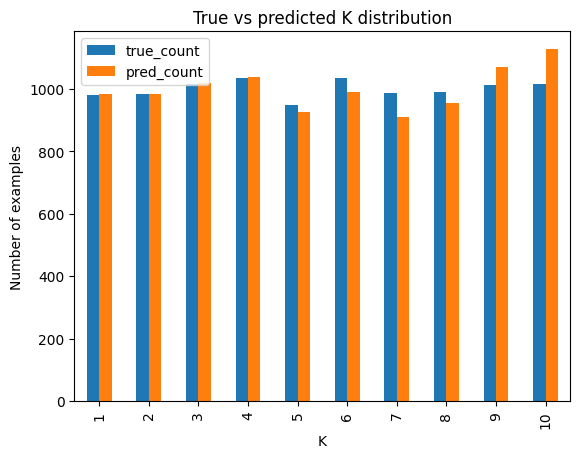

In [19]:
pd.DataFrame({
    "true_count": df.true_K.value_counts().sort_index(),
    "pred_count": df.pred_K.value_counts().sort_index(),
}).plot(kind="bar")
plt.xlabel("K")
plt.ylabel("Number of examples")
plt.title("True vs predicted K distribution")
plt.show()
